<a href="https://colab.research.google.com/github/ayushhh026/RuppeRisk/blob/main/notebooks/MODEL11_Finalization_SHAP_Business_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Drive and import required libraries
from google.colab import drive
drive.mount("/content/drive")

import os
import gc
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")

print("Setup complete.")

Mounted at /content/drive
Setup complete.


In [2]:
# Define paths for Model11 artifacts and final outputs
RESULTS_PATH = "/content/drive/MyDrive/RupeeRisk/"

MODEL11_MODEL_PATH = RESULTS_PATH + "rupeerisk_model11_optuna_xgb.joblib"
MODEL11_DATA_PATH = RESULTS_PATH + "model10_recommended_features.parquet"
FINAL_MODEL_PATH = RESULTS_PATH + "rupeerisk_final_model.joblib"
FINAL_RESULTS_PATH = RESULTS_PATH + "rupeerisk_final_model_results.csv"

print("Model11 model:", MODEL11_MODEL_PATH)
print("Model11 dataset:", MODEL11_DATA_PATH)

Model11 model: /content/drive/MyDrive/RupeeRisk/rupeerisk_model11_optuna_xgb.joblib
Model11 dataset: /content/drive/MyDrive/RupeeRisk/model10_recommended_features.parquet


In [3]:
# Model11 was saved as a full sklearn Pipeline object, not a dict bundle
if not os.path.exists(MODEL11_MODEL_PATH):
    raise FileNotFoundError(f"Model11 artifact not found:\n{MODEL11_MODEL_PATH}")

best_pipeline = joblib.load(MODEL11_MODEL_PATH)

print("Model11 pipeline loaded.")
print("Pipeline steps:", best_pipeline.named_steps.keys())

Model11 pipeline loaded.
Pipeline steps: dict_keys(['preprocessor', 'model'])


In [4]:
# Pull the two components out of the pipeline via named_steps
model11 = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

print("Model type:", type(model11).__name__)

Model type: XGBClassifier


In [7]:
# Load the same dataset Model11 was trained on
model11_data = pd.read_parquet(MODEL11_DATA_PATH)

print("Dataset shape:", model11_data.shape)
print("TARGET present:", "TARGET" in model11_data.columns)
print("SK_ID_CURR present:", "SK_ID_CURR" in model11_data.columns)

Dataset shape: (307511, 304)
TARGET present: True
SK_ID_CURR present: False


In [8]:
# Same split parameters used throughout the project
y = model11_data["TARGET"].copy()
X = model11_data.drop(columns=["TARGET"]).copy()

if "SK_ID_CURR" in X.columns:
    X = X.drop(columns=["SK_ID_CURR"])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)

Training shape: (246008, 303)
Validation shape: (61503, 303)


In [9]:
# Use the already-fitted preprocessor, do not refit
X_valid_transformed = preprocessor.transform(X_valid)

print("Transformed validation shape:", X_valid_transformed.shape)

Transformed validation shape: (61503, 433)


In [10]:
# Confirm the reload reproduces the known Model11 result
valid_proba = model11.predict_proba(X_valid_transformed)[:, 1]

final_roc_auc = roc_auc_score(y_valid, valid_proba)
final_pr_auc = average_precision_score(y_valid, valid_proba)

print("============================================================")
print("MODEL11 FINAL BENCHMARK")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"PR-AUC:  {final_pr_auc:.4f}")
print("Expected: ROC-AUC 0.7882, PR-AUC 0.2905")
print("============================================================")

MODEL11 FINAL BENCHMARK
ROC-AUC: 0.7882
PR-AUC:  0.2905
Expected: ROC-AUC 0.7882, PR-AUC 0.2905


In [11]:
# Create a TreeExplainer directly on the XGBoost model (not the pipeline)
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(model11)
print("SHAP explainer ready.")

Creating SHAP explainer...
SHAP explainer ready.


In [12]:
# Use a representative sample rather than all 61k rows, to keep memory reasonable
SHAP_SAMPLE_SIZE = min(5000, X_valid_transformed.shape[0])

rng = np.random.RandomState(42)
sample_indices = rng.choice(X_valid_transformed.shape[0], size=SHAP_SAMPLE_SIZE, replace=False)

X_shap = X_valid_transformed[sample_indices]

print("SHAP sample size:", X_shap.shape)

SHAP sample size: (5000, 433)


In [13]:
# Compute SHAP values for the sample
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", np.array(shap_values).shape)

Calculating SHAP values...
SHAP values shape: (5000, 433)


In [14]:
# Get the post-one-hot-encoding feature names from the fitted preprocessor
feature_names = preprocessor.get_feature_names_out()

print("Transformed feature count:", len(feature_names))
print("SHAP feature count:", shap_values.shape[1])

Transformed feature count: 433
SHAP feature count: 433


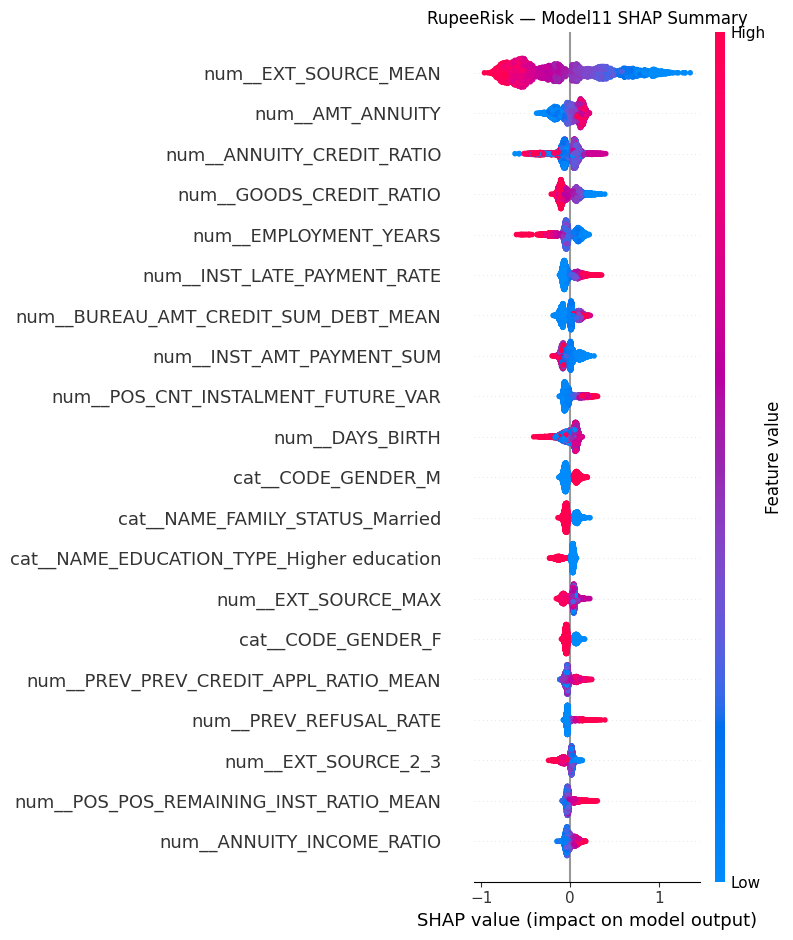

In [15]:
# Visualize the top 20 most impactful features
plt.figure(figsize=(12, 8))

shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False, max_display=20)

plt.title("RupeeRisk — Model11 SHAP Summary")
plt.tight_layout()
plt.show()

In [16]:
# Build a ranked table of mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

display(shap_importance.head(20))

,Feature,Mean_Abs_SHAP
0,num__EXT_SOURCE_MEAN,0.464788
1,num__AMT_ANNUITY,0.100297
2,num__ANNUITY_CREDIT_RATIO,0.098226
3,num__GOODS_CREDIT_RATIO,0.095978
4,num__EMPLOYMENT_YEARS,0.091663
5,num__INST_LATE_PAYMENT_RATE,0.070244
6,num__BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,0.069331
7,num__INST_AMT_PAYMENT_SUM,0.066415
8,num__POS_CNT_INSTALMENT_FUTURE_VAR,0.064390
9,num__DAYS_BIRTH,0.063111


In [17]:
# Save the full SHAP importance ranking
SHAP_IMPORTANCE_PATH = RESULTS_PATH + "model11_shap_feature_importance.csv"
shap_importance.to_csv(SHAP_IMPORTANCE_PATH, index=False)

print("SHAP importance saved:", SHAP_IMPORTANCE_PATH)

SHAP importance saved: /content/drive/MyDrive/RupeeRisk/model11_shap_feature_importance.csv


In [18]:
# ROC-AUC alone doesn't tell us what decision threshold to use in practice
thresholds = np.arange(0.05, 0.56, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred = (valid_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, y_pred, zero_division=0),
        "Recall": recall_score(y_valid, y_pred, zero_division=0),
        "F1": f1_score(y_valid, y_pred, zero_division=0),
        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results)

,Threshold,Precision,Recall,F1,True_Negatives,False_Positives,False_Negatives,True_Positives
0,0.05,0.141777,0.838671,0.242551,31332,25206,801,4164
1,0.10,0.210766,0.642699,0.317433,44589,11949,1774,3191
2,0.15,0.265217,0.476536,0.340775,49983,6555,2599,2366
3,0.20,0.321056,0.359919,0.339379,52759,3779,3178,1787
4,0.25,0.370339,0.266062,0.309658,54292,2246,3644,1321
5,0.30,0.407696,0.189930,0.259137,55168,1370,4022,943
6,0.35,0.455466,0.135952,0.209400,55731,807,4290,675
7,0.40,0.502053,0.098489,0.164674,56053,485,4476,489
8,0.45,0.553125,0.071299,0.126316,56252,286,4611,354
9,0.50,0.586563,0.045720,0.084828,56378,160,4738,227


In [19]:
# Select the threshold that maximizes F1
best_f1_row = threshold_results.loc[threshold_results["F1"].idxmax()]
BEST_THRESHOLD = best_f1_row["Threshold"]

print("Best F1 threshold:", BEST_THRESHOLD)
print(f"Precision: {best_f1_row['Precision']:.4f}")
print(f"Recall:    {best_f1_row['Recall']:.4f}")
print(f"F1:        {best_f1_row['F1']:.4f}")

Best F1 threshold: 0.15000000000000002
Precision: 0.2652
Recall:    0.4765
F1:        0.3408


In [20]:
# Full classification report and confusion matrix at the chosen threshold
y_pred_final = (valid_proba >= BEST_THRESHOLD).astype(int)

print(classification_report(y_valid, y_pred_final, digits=4))

print("Confusion matrix:")
display(pd.DataFrame(
    confusion_matrix(y_valid, y_pred_final),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

              precision    recall  f1-score   support

           0     0.9506    0.8841    0.9161     56538
           1     0.2652    0.4765    0.3408      4965

    accuracy                         0.8512     61503
   macro avg     0.6079    0.6803    0.6284     61503
weighted avg     0.8952    0.8512    0.8697     61503

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,49983,6555
Actual 1,2599,2366


In [21]:
# Save the final model with its threshold and validation metrics for deployment
final_model_bundle = {
    "model": model11,
    "preprocessor": preprocessor,
    "threshold": float(BEST_THRESHOLD),
    "validation_roc_auc": float(final_roc_auc),
    "validation_pr_auc": float(final_pr_auc),
    "validation_precision": float(best_f1_row["Precision"]),
    "validation_recall": float(best_f1_row["Recall"]),
    "validation_f1": float(best_f1_row["F1"]),
    "feature_count": int(X.shape[1]),
    "model_name": "RupeeRisk_Model11_Final"
}

joblib.dump(final_model_bundle, FINAL_MODEL_PATH)
print("Final model saved:", FINAL_MODEL_PATH)

Final model saved: /content/drive/MyDrive/RupeeRisk/rupeerisk_final_model.joblib


In [22]:
# Summary table of the final model's key metrics
final_results = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Decision Threshold", "Precision", "Recall", "F1", "Feature Count"],
    "Value": [
        final_roc_auc, final_pr_auc, BEST_THRESHOLD,
        best_f1_row["Precision"], best_f1_row["Recall"], best_f1_row["F1"], X.shape[1]
    ]
})

display(final_results)

,Metric,Value
0,ROC-AUC,0.788152
1,PR-AUC,0.290469
2,Decision Threshold,0.150000
3,Precision,0.265217
4,Recall,0.476536
5,F1,0.340775
6,Feature Count,303.000000


In [23]:
# Save the final metrics table
final_results.to_csv(FINAL_RESULTS_PATH, index=False)
print("Final results saved:", FINAL_RESULTS_PATH)

Final results saved: /content/drive/MyDrive/RupeeRisk/rupeerisk_final_model_results.csv


In [24]:
# Print the overall project summary
# NOTE: confirm the actual Model12 exploratory numbers before running this,
# or remove the specific figures if you haven't verified them yourself.
print("""
RUPEERISK FINAL MODEL

Final model: MODEL11 — XGBoost + engineered application/history features

ROC-AUC:  {:.4f}
PR-AUC:   {:.4f}
Decision threshold: {:.4f}
Precision: {:.4f}
Recall:    {:.4f}
F1:        {:.4f}
Feature count: {}

Model12 (reference-inspired feature set) was explored as a side experiment
but not selected as the final model, since it combined multiple feature and
training changes simultaneously and could not be cleanly attributed feature-by-feature.
""".format(
    final_roc_auc, final_pr_auc, BEST_THRESHOLD,
    best_f1_row["Precision"], best_f1_row["Recall"], best_f1_row["F1"], X.shape[1]
))


RUPEERISK FINAL MODEL

Final model: MODEL11 — XGBoost + engineered application/history features

ROC-AUC:  0.7882
PR-AUC:   0.2905
Decision threshold: 0.1500
Precision: 0.2652
Recall:    0.4765
F1:        0.3408
Feature count: 303

Model12 (reference-inspired feature set) was explored as a side experiment
but not selected as the final model, since it combined multiple feature and
training changes simultaneously and could not be cleanly attributed feature-by-feature.



In [25]:
# Final cleanup
del X, X_train, X_valid, y, y_train, y_valid, X_valid_transformed, X_shap, shap_values
gc.collect()

print("Final cleanup complete.")
!free -h

Final cleanup complete.
               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.9Gi       4.9Gi       2.0Mi       3.9Gi       8.5Gi
Swap:             0B          0B          0B


In [26]:
# XGBoost built-in feature importance
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model11.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(xgb_importance.head(20))

,Feature,Importance
0,num__EXT_SOURCE_MEAN,0.073152
1,num__EXT_SOURCE_MIN,0.010216
2,cat__NAME_EDUCATION_TYPE_Higher education,0.010210
3,cat__NAME_INCOME_TYPE_Pensioner,0.009430
4,cat__CODE_GENDER_M,0.008230
5,num__CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,0.007221
6,num__FLAG_DOCUMENT_3,0.006612
7,cat__NAME_INCOME_TYPE_Working,0.006548
8,num__EXT_SOURCE_2_3,0.006406
9,num__GOODS_CREDIT_RATIO,0.006397


In [27]:
booster = model11.get_booster()

gain_importance = booster.get_score(
    importance_type="gain"
)

gain_importance = pd.DataFrame(
    gain_importance.items(),
    columns=["Feature", "Gain"]
).sort_values(
    "Gain",
    ascending=False
).reset_index(drop=True)

display(gain_importance.head(20))

,Feature,Gain
0,f79,371.401184
1,f80,51.865246
2,f313,51.835167
3,f307,47.874905
4,f290,41.783443
5,f257,36.662884
6,f46,33.569324
7,f311,33.246155
8,f85,32.521362
9,f78,32.475880


In [28]:
booster = model11.get_booster()

importance_types = [
    "weight",
    "gain",
    "cover",
    "total_gain",
    "total_cover"
]

for importance_type in importance_types:
    print(f"\n=== {importance_type.upper()} ===")

    importance_dict = booster.get_score(
        importance_type=importance_type
    )

    importance_df = (
        pd.DataFrame(
            importance_dict.items(),
            columns=["Feature", "Importance"]
        )
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(
        importance_df.head(20)
    )


=== WEIGHT ===


,Feature,Importance
0,f77,554.0
1,f5,435.0
2,f2,368.0
3,f74,366.0
4,f79,352.0
5,f76,339.0
6,f7,302.0
7,f138,301.0
8,f78,300.0
9,f175,275.0



=== GAIN ===


,Feature,Importance
0,f79,371.401184
1,f80,51.865246
2,f313,51.835167
3,f307,47.874905
4,f290,41.783443
5,f257,36.662884
6,f46,33.569324
7,f311,33.246155
8,f85,32.521362
9,f78,32.475880



=== COVER ===


,Feature,Importance
0,f391,13180.265625
1,f329,12600.954102
2,f125,12442.393555
3,f401,12408.858398
4,f416,12264.720703
5,f385,12174.032227
6,f340,12097.575195
7,f11,12077.857422
8,f386,11965.368164
9,f177,11629.965820



=== TOTAL_GAIN ===


,Feature,Importance
0,f79,130733.218750
1,f77,13569.070312
2,f80,12188.333008
3,f78,9742.763672
4,f5,9158.849609
5,f74,8094.740234
6,f2,7185.192871
7,f81,6992.922852
8,f216,6945.047852
9,f98,6347.697266



=== TOTAL_COVER ===


,Feature,Importance
0,f77,1.909667e+06
1,f79,1.719879e+06
2,f2,1.043160e+06
3,f5,9.629867e+05
4,f74,8.934785e+05
5,f119,7.522452e+05
6,f175,6.720215e+05
7,f7,6.228811e+05
8,f78,6.160026e+05
9,f138,6.020693e+05


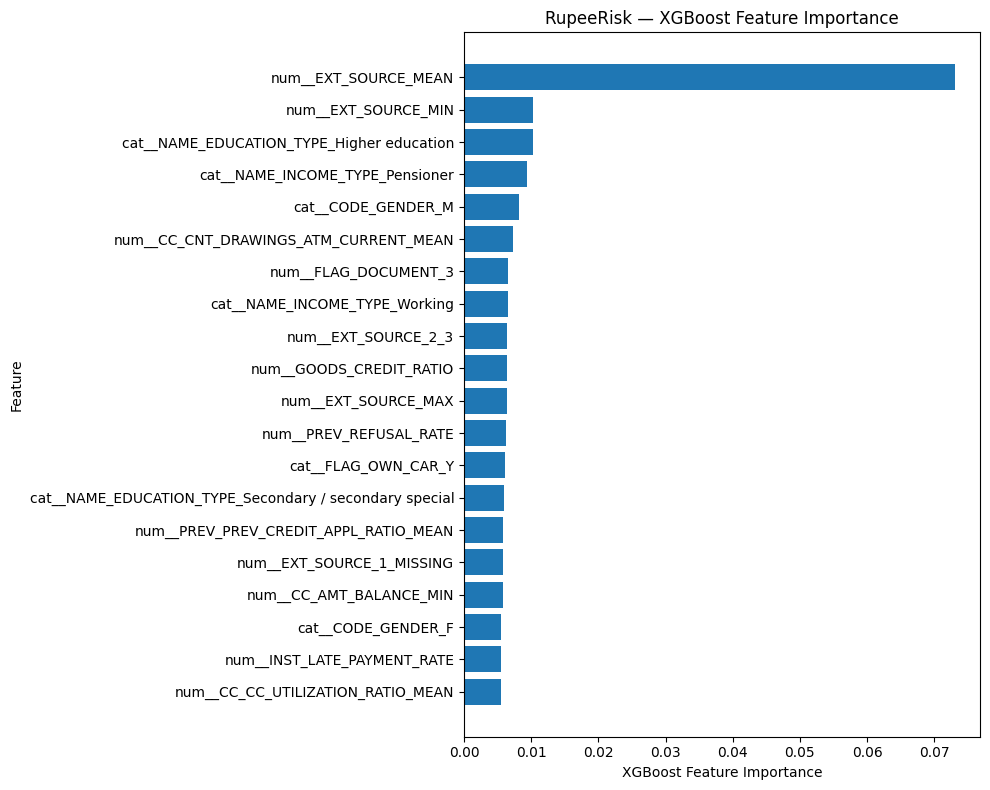

In [29]:
plt.figure(figsize=(10, 8))

top20 = xgb_importance.head(20).sort_values(
    "Importance"
)

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("RupeeRisk — XGBoost Feature Importance")

plt.tight_layout()
plt.show()